# Employee Attrition Prediction Using Random Forest Classifier

## Machine Learning Assignment – Supervised Learning

### Problem Description
Employee attrition is a major issue for organizations because losing employees increases recruitment costs, training costs, and reduces productivity. This project applies a Random Forest Classifier to predict whether an employee will leave the company (`Yes`) or stay (`No`) based on various personal and job-related attributes.

### Dataset Source
IBM HR Analytics Attrition Dataset

### Target Variable
**Attrition**
- Yes = Employee leaves
- No = Employee stays

In [1]:
# ============================================================
# EMPLOYEE ATTRITION PREDICTION USING RANDOM FOREST
# Machine Learning Assignment - Supervised Learning
# ============================================================

# =========================
# 1. IMPORT LIBRARIES
# =========================
import os
import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

from google.colab import drive, files

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    cross_val_score,
    StratifiedKFold
)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

print("All libraries imported successfully!")

All libraries imported successfully!


## Google Drive Mounting

Google Drive is mounted so that all generated files such as graphs, processed datasets, prediction outputs, and trained models can be saved permanently.

In [2]:
# =========================
# 2. MOUNT GOOGLE DRIVE
# =========================
drive.mount('/content/drive')

Mounted at /content/drive


## Create Project Folder

A dedicated project folder is created in Google Drive to store all outputs related to this assignment.

In [3]:
# =========================
# 3. CREATE PROJECT FOLDER
# =========================
project_folder = "/content/drive/MyDrive/ML_Assignment_Attrition"
os.makedirs(project_folder, exist_ok=True)

print("Project folder ready:", project_folder)

Project folder ready: /content/drive/MyDrive/ML_Assignment_Attrition


## Load Dataset

The IBM HR Analytics Attrition dataset is uploaded and loaded into a pandas DataFrame for analysis.

In [4]:
# =========================
# 4. UPLOAD DATASET
# =========================
uploaded = files.upload()

Saving WA_Fn-UseC_-HR-Employee-Attrition.csv to WA_Fn-UseC_-HR-Employee-Attrition.csv


In [5]:
# Read uploaded CSV file
file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)
df.head()

Dataset loaded successfully!
Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [6]:
# Save original dataset copy to Google Drive
df.to_csv(f"{project_folder}/original_dataset_copy.csv", index=False)
print("Original dataset copy saved to Google Drive.")

Original dataset copy saved to Google Drive.


## Dataset Description

The dataset contains employee-level information such as age, business travel, income, job satisfaction, work-life balance, and years at the company.

### Example Features
- Age
- BusinessTravel
- Department
- DistanceFromHome
- Education
- JobRole
- MonthlyIncome
- OverTime
- TotalWorkingYears
- WorkLifeBalance
- YearsAtCompany

### Dataset Size
The dataset contains 1470 rows and 35 columns before preprocessing.

In [7]:
# =========================
# 5. BASIC DATASET INSPECTION
# =========================
print("Shape of dataset:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

Shape of dataset: (1470, 35)

Column names:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Data types:
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeN

In [8]:
# Statistical summary
df.describe(include="all")

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470,1470,1470.000000,1470,1470.000000,1470.000000,1470,1470.0,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
unique,NaN,2,3,NaN,3,NaN,NaN,6,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,No,Travel_Rarely,NaN,Research & Development,NaN,NaN,Life Sciences,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,1233,1043,NaN,961,NaN,NaN,606,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,36.923810,NaN,NaN,802.485714,NaN,9.192517,2.912925,NaN,1.0,1024.865306,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,NaN,NaN,403.509100,NaN,8.106864,1.024165,NaN,0.0,602.024335,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,NaN,NaN,102.000000,NaN,1.000000,1.000000,NaN,1.0,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,NaN,NaN,465.000000,NaN,2.000000,2.000000,NaN,1.0,491.250000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,NaN,NaN,802.000000,NaN,7.000000,3.000000,NaN,1.0,1020.500000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,NaN,NaN,1157.000000,NaN,14.000000,4.000000,NaN,1.0,1555.750000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000


## Exploratory Data Analysis (EDA)

EDA is used to understand the class distribution and the relationship between selected features and employee attrition.

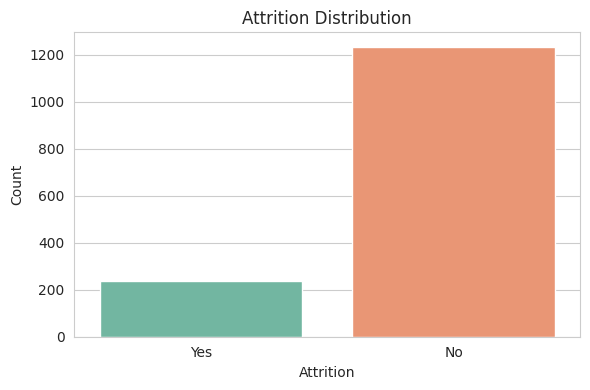

Attrition
No     1233
Yes     237
Name: count, dtype: int64


In [9]:
# =========================
# 6. TARGET VARIABLE DISTRIBUTION
# =========================
plt.figure(figsize=(6, 4))
sns.countplot(x="Attrition", data=df, palette="Set2")
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print(df["Attrition"].value_counts())

In [10]:
plt.figure(figsize=(6, 4))
sns.countplot(x="Attrition", data=df, palette="Set2")
plt.title("Attrition Distribution")
plt.xlabel("Attrition")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(f"{project_folder}/attrition_distribution.png")
plt.close()

print("Attrition distribution chart saved.")

Attrition distribution chart saved.


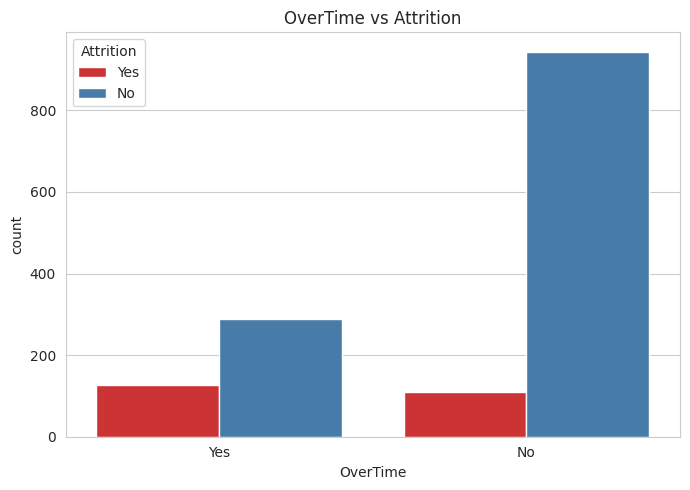

In [11]:
# OverTime vs Attrition
plt.figure(figsize=(7, 5))
sns.countplot(x="OverTime", hue="Attrition", data=df, palette="Set1")
plt.title("OverTime vs Attrition")
plt.tight_layout()
plt.show()

In [12]:
plt.figure(figsize=(7, 5))
sns.countplot(x="OverTime", hue="Attrition", data=df, palette="Set1")
plt.title("OverTime vs Attrition")
plt.tight_layout()
plt.savefig(f"{project_folder}/overtime_vs_attrition.png")
plt.close()

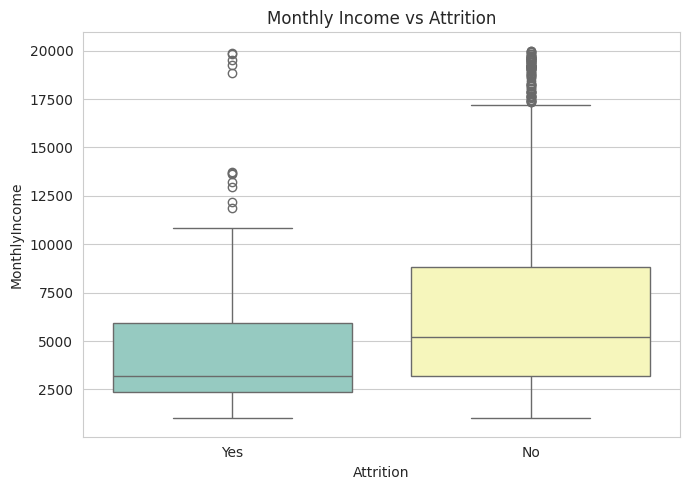

In [13]:
# MonthlyIncome vs Attrition
plt.figure(figsize=(7, 5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, palette="Set3")
plt.title("Monthly Income vs Attrition")
plt.tight_layout()
plt.show()

In [14]:
plt.figure(figsize=(7, 5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=df, palette="Set3")
plt.title("Monthly Income vs Attrition")
plt.tight_layout()
plt.savefig(f"{project_folder}/monthly_income_vs_attrition.png")
plt.close()

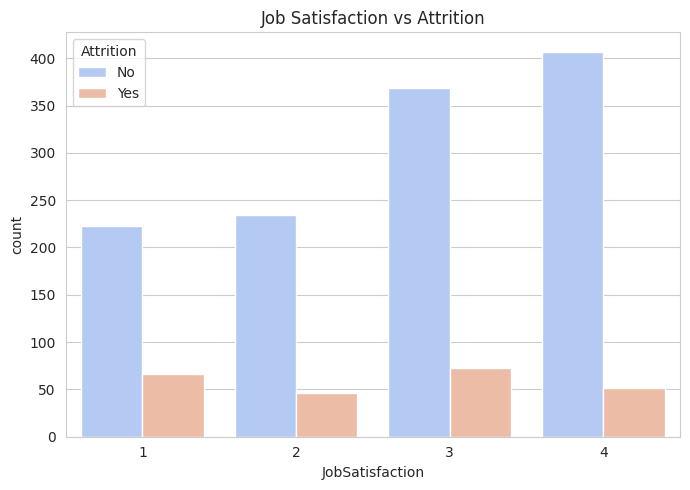

In [15]:
# JobSatisfaction vs Attrition
plt.figure(figsize=(7, 5))
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df, palette="coolwarm")
plt.title("Job Satisfaction vs Attrition")
plt.tight_layout()
plt.show()

In [16]:
plt.figure(figsize=(7, 5))
sns.countplot(x="JobSatisfaction", hue="Attrition", data=df, palette="coolwarm")
plt.title("Job Satisfaction vs Attrition")
plt.tight_layout()
plt.savefig(f"{project_folder}/job_satisfaction_vs_attrition.png")
plt.close()

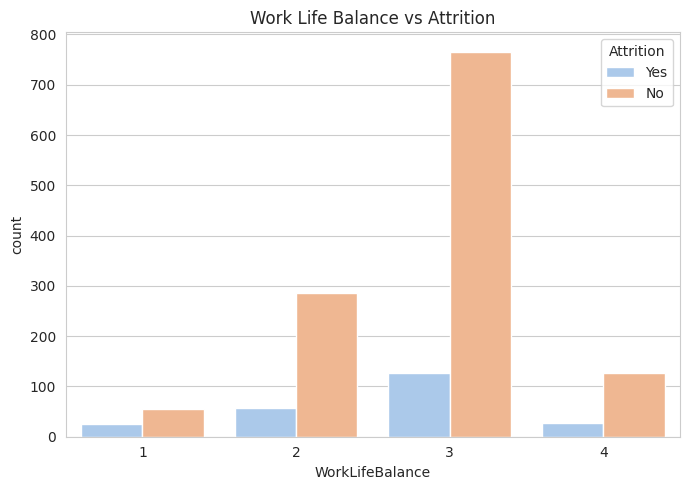

In [17]:
# WorkLifeBalance vs Attrition
plt.figure(figsize=(7, 5))
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df, palette="pastel")
plt.title("Work Life Balance vs Attrition")
plt.tight_layout()
plt.show()

In [18]:
plt.figure(figsize=(7, 5))
sns.countplot(x="WorkLifeBalance", hue="Attrition", data=df, palette="pastel")
plt.title("Work Life Balance vs Attrition")
plt.tight_layout()
plt.savefig(f"{project_folder}/worklifebalance_vs_attrition.png")
plt.close()

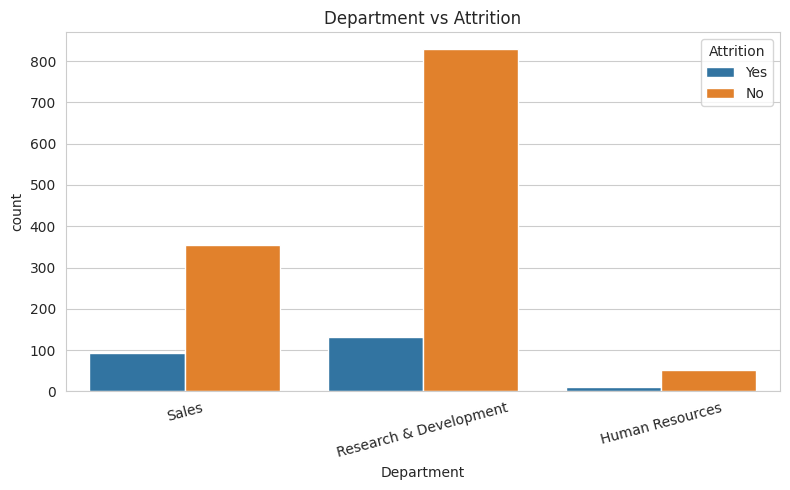

In [19]:
# Department vs Attrition
plt.figure(figsize=(8, 5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Department vs Attrition")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

In [20]:
plt.figure(figsize=(8, 5))
sns.countplot(x="Department", hue="Attrition", data=df)
plt.title("Department vs Attrition")
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig(f"{project_folder}/department_vs_attrition.png")
plt.close()

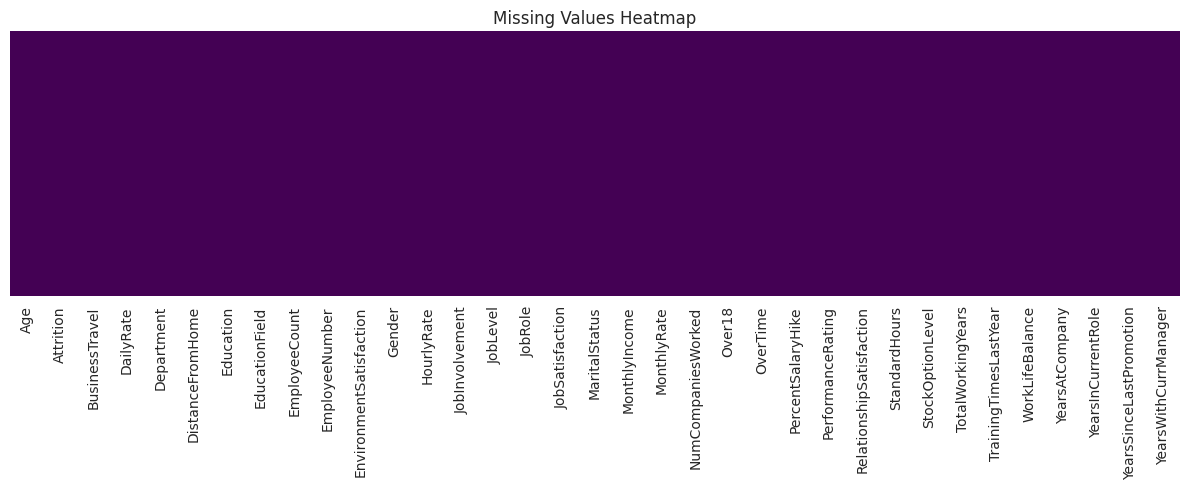


Missing value count:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EmployeeCount               0
EmployeeNumber              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
Over18                      0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StandardHours               0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole

In [21]:
# Missing value heatmap
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.show()

print("\nMissing value count:")
print(df.isnull().sum())

In [22]:
plt.figure(figsize=(12, 5))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap="viridis")
plt.title("Missing Values Heatmap")
plt.tight_layout()
plt.savefig(f"{project_folder}/missing_values_heatmap.png")
plt.close()

## Data Preprocessing

The preprocessing stage includes:
- removing irrelevant columns
- handling missing values
- feature engineering
- log transformation
- encoding categorical variables
- scaling the data

In [23]:
# =========================
# 7. DATA PREPROCESSING
# =========================

# Drop irrelevant columns
columns_to_drop = ["EmployeeCount", "EmployeeNumber", "Over18", "StandardHours"]

for col in columns_to_drop:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("Updated dataset shape after dropping irrelevant columns:", df.shape)

Updated dataset shape after dropping irrelevant columns: (1470, 31)


In [24]:
# Handle missing values
for col in df.columns:
    if df[col].dtype == "object":
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print("Remaining missing values after preprocessing:", df.isnull().sum().sum())

Remaining missing values after preprocessing: 0


## Feature Engineering

New features are created to improve the model’s ability to capture hidden patterns in the data.

### Engineered Features
- **IncomePerYearAtCompany**
- **YearsSinceLastPromotionRatio**
- **TotalSatisfaction**
- **IncomeToDistanceRatio**
- **YearsWithManagerRatio**
- **CareerStagnation**

In [25]:
# =========================
# 8. FEATURE ENGINEERING
# =========================
df["IncomePerYearAtCompany"] = df["MonthlyIncome"] / (df["YearsAtCompany"] + 1)
df["YearsSinceLastPromotionRatio"] = df["YearsSinceLastPromotion"] / (df["YearsAtCompany"] + 1)
df["TotalSatisfaction"] = (
    df["JobSatisfaction"] +
    df["EnvironmentSatisfaction"] +
    df["RelationshipSatisfaction"]
)
df["IncomeToDistanceRatio"] = df["MonthlyIncome"] / (df["DistanceFromHome"] + 1)
df["YearsWithManagerRatio"] = df["YearsWithCurrManager"] / (df["YearsAtCompany"] + 1)
df["CareerStagnation"] = df["YearsInCurrentRole"] - df["YearsSinceLastPromotion"]

print("New engineered features added successfully!")
df[[
    "IncomePerYearAtCompany",
    "YearsSinceLastPromotionRatio",
    "TotalSatisfaction",
    "IncomeToDistanceRatio",
    "YearsWithManagerRatio",
    "CareerStagnation"
]].head()

New engineered features added successfully!


,IncomePerYearAtCompany,YearsSinceLastPromotionRatio,TotalSatisfaction,IncomeToDistanceRatio,YearsWithManagerRatio,CareerStagnation
0,856.142857,0.000000,7,2996.500000,0.714286,4
1,466.363636,0.090909,9,570.000000,0.636364,6
2,2090.000000,0.000000,9,696.666667,0.000000,0
3,323.222222,0.333333,10,727.250000,0.000000,4
4,1156.000000,0.666667,7,1156.000000,0.666667,0


## Log Transformation

Selected numerical features are log-transformed to reduce skewness and improve numerical stability.

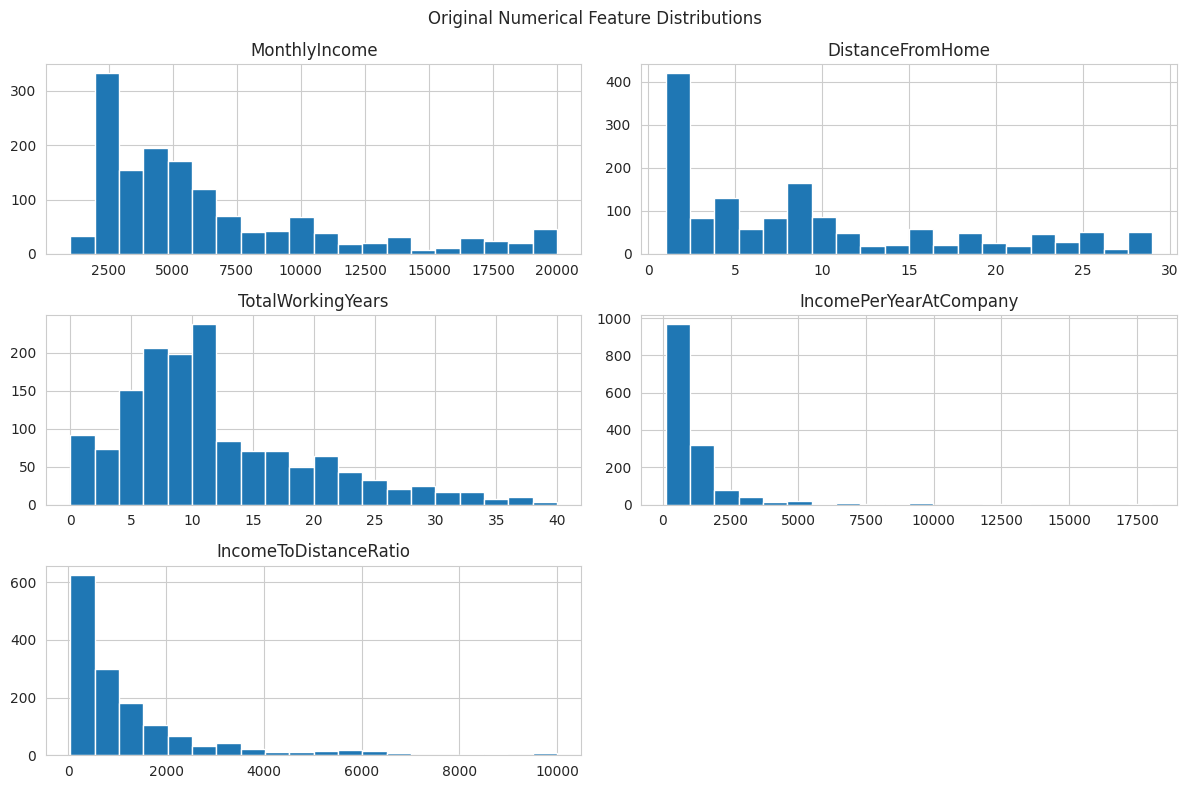

In [26]:
# =========================
# 9. SKEWNESS CHECK AND LOG TRANSFORMATION
# =========================
numeric_cols = [
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "IncomePerYearAtCompany",
    "IncomeToDistanceRatio"
]

df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Original Numerical Feature Distributions")
plt.tight_layout()
plt.show()

In [27]:
df[numeric_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Original Numerical Feature Distributions")
plt.tight_layout()
plt.savefig(f"{project_folder}/original_numeric_distributions.png")
plt.close()

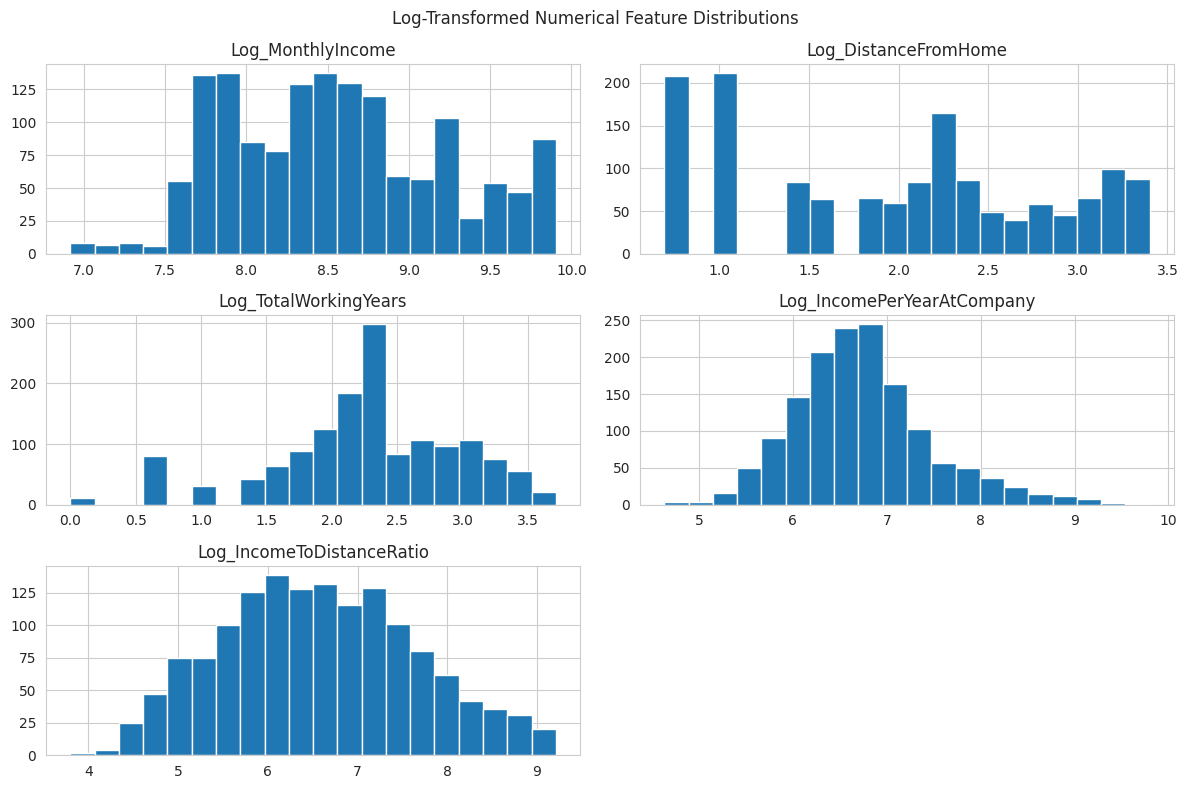

In [28]:
# Apply log transformation
for col in [
    "MonthlyIncome",
    "DistanceFromHome",
    "TotalWorkingYears",
    "IncomePerYearAtCompany",
    "IncomeToDistanceRatio"
]:
    if col in df.columns:
        df[f"Log_{col}"] = np.log1p(df[col])

log_cols = [
    "Log_MonthlyIncome",
    "Log_DistanceFromHome",
    "Log_TotalWorkingYears",
    "Log_IncomePerYearAtCompany",
    "Log_IncomeToDistanceRatio"
]

df[log_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Log-Transformed Numerical Feature Distributions")
plt.tight_layout()
plt.show()

In [29]:
df[log_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Log-Transformed Numerical Feature Distributions")
plt.tight_layout()
plt.savefig(f"{project_folder}/log_transformed_distributions.png")
plt.close()

## Encoding

Categorical variables are converted into numeric form so that the Random Forest classifier can process them.

In [30]:
# =========================
# 10. ENCODE TARGET VARIABLE
# =========================
df["Attrition"] = df["Attrition"].map({"Yes": 1, "No": 0})

print("Target variable encoding completed.")
print(df["Attrition"].value_counts())

Target variable encoding completed.
Attrition
0    1233
1     237
Name: count, dtype: int64


In [31]:
# Encode categorical variables
label_encoders = {}

for col in df.select_dtypes(include="object").columns:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col].astype(str))
    label_encoders[col] = le

print("Categorical columns encoded successfully.")
df.head()

Categorical columns encoded successfully.


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,YearsSinceLastPromotionRatio,TotalSatisfaction,IncomeToDistanceRatio,YearsWithManagerRatio,CareerStagnation,Log_MonthlyIncome,Log_DistanceFromHome,Log_TotalWorkingYears,Log_IncomePerYearAtCompany,Log_IncomeToDistanceRatio
0,41,1,2,1102,2,1,2,1,2,0,...,0.000000,7,2996.500000,0.714286,4,8.698514,0.693147,2.197225,6.753605,8.005534
1,49,0,1,279,1,8,1,1,3,1,...,0.090909,9,570.000000,0.636364,6,8.543056,2.197225,2.397895,6.147108,6.347389
2,37,1,2,1373,1,2,2,4,4,1,...,0.000000,9,696.666667,0.000000,0,7.645398,1.098612,2.079442,7.645398,6.547741
3,33,0,1,1392,1,3,4,1,4,0,...,0.333333,10,727.250000,0.000000,4,7.975908,1.386294,2.197225,5.781429,6.590644
4,27,0,2,591,1,2,1,3,1,1,...,0.666667,7,1156.000000,0.666667,0,8.151622,1.098612,1.945910,7.053586,7.053586


In [32]:
# Save processed dataset
df.to_csv(f"{project_folder}/processed_attrition_dataset.csv", index=False)
print("Processed dataset saved to Google Drive.")

Processed dataset saved to Google Drive.


## Correlation Analysis

A correlation heatmap is used to understand the relationships among the variables.

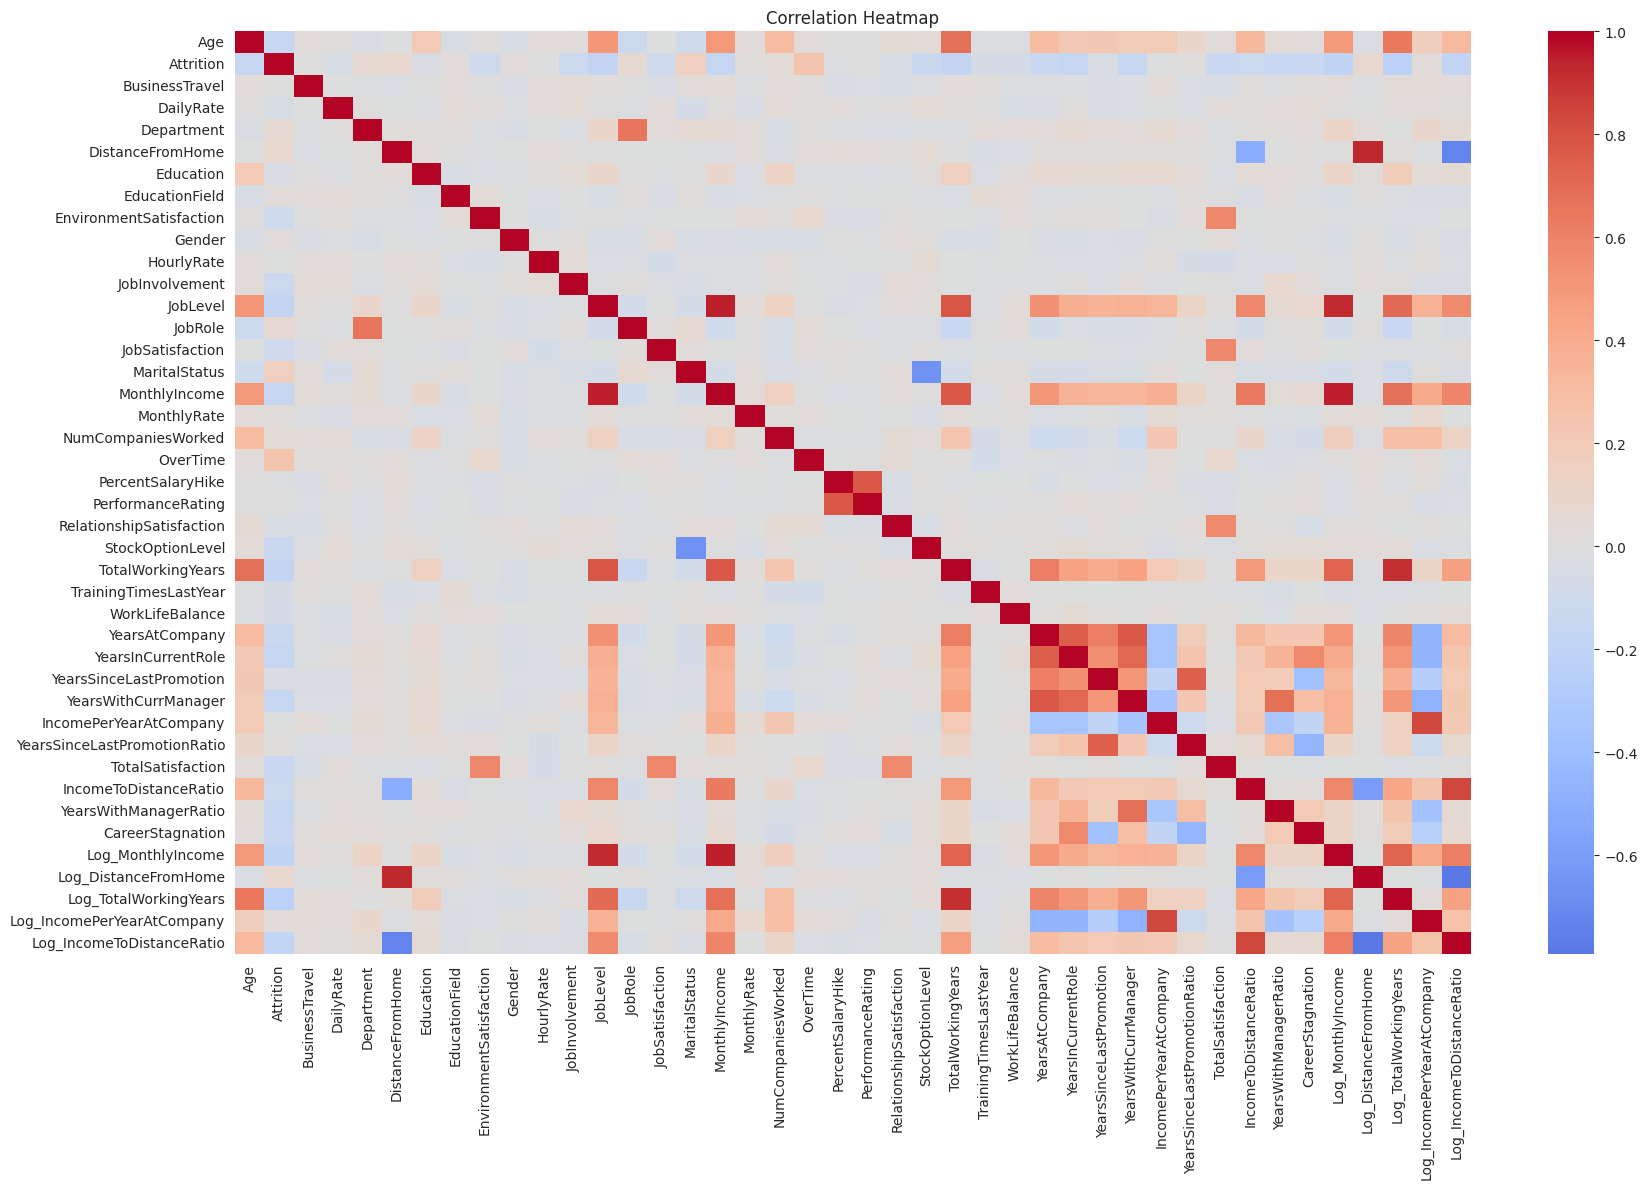

In [33]:
# =========================
# 11. CORRELATION ANALYSIS
# =========================
plt.figure(figsize=(18, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

In [34]:
plt.figure(figsize=(18, 12))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig(f"{project_folder}/correlation_heatmap.png")
plt.close()

## Train-Test Split

The dataset is divided into training and testing subsets using an 80:20 ratio, while preserving the class distribution through stratification.

In [35]:
# =========================
# 12. DEFINE FEATURES AND TARGET
# =========================
X = df.drop("Attrition", axis=1)
y = df["Attrition"]

print("Feature set shape:", X.shape)
print("Target shape:", y.shape)

print("\nClass distribution:")
print(y.value_counts())

Feature set shape: (1470, 41)
Target shape: (1470,)

Class distribution:
Attrition
0    1233
1     237
Name: count, dtype: int64


In [36]:
# =========================
# 13. TRAIN-TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(f"Training set   : {X_train.shape[0]} samples")
print(f"Testing set    : {X_test.shape[0]} samples")

Training set   : 1176 samples
Testing set    : 294 samples


## Feature Scaling

Although Random Forest does not strictly require feature scaling, scaling is applied here for consistency in preprocessing.

In [37]:
# =========================
# 14. FEATURE SCALING
# =========================
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed.")

Feature scaling completed.


## Baseline Random Forest Model

A baseline Random Forest model is first trained to establish the initial performance before hyperparameter tuning.

In [39]:
# =========================
# 15. BASELINE RANDOM FOREST MODEL
# =========================
rf_baseline = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

rf_baseline.fit(X_train_scaled, y_train)

y_pred_baseline = rf_baseline.predict(X_test_scaled)
y_prob_baseline = rf_baseline.predict_proba(X_test_scaled)[:, 1]

baseline_acc = accuracy_score(y_test, y_pred_baseline)
baseline_precision = precision_score(y_test, y_pred_baseline, zero_division=0)
baseline_recall = recall_score(y_test, y_pred_baseline, zero_division=0)
baseline_f1 = f1_score(y_test, y_pred_baseline, zero_division=0)
baseline_auc = roc_auc_score(y_test, y_prob_baseline)

print("Baseline Random Forest Results")
print("=" * 40)
print(f"Accuracy  : {baseline_acc:.4f} ({baseline_acc*100:.2f}%)")
print(f"Precision : {baseline_precision:.4f}")
print(f"Recall    : {baseline_recall:.4f}")
print(f"F1-Score  : {baseline_f1:.4f}")
print(f"ROC-AUC   : {baseline_auc:.4f}")

Baseline Random Forest Results
Accuracy  : 0.8299 (82.99%)
Precision : 0.3333
Recall    : 0.0638
F1-Score  : 0.1071
ROC-AUC   : 0.7778


In [40]:
print("Classification Report (Baseline):\n")
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

Classification Report (Baseline):

              precision    recall  f1-score   support

No Attrition       0.85      0.98      0.91       247
   Attrition       0.33      0.06      0.11        47

    accuracy                           0.83       294
   macro avg       0.59      0.52      0.51       294
weighted avg       0.76      0.83      0.78       294



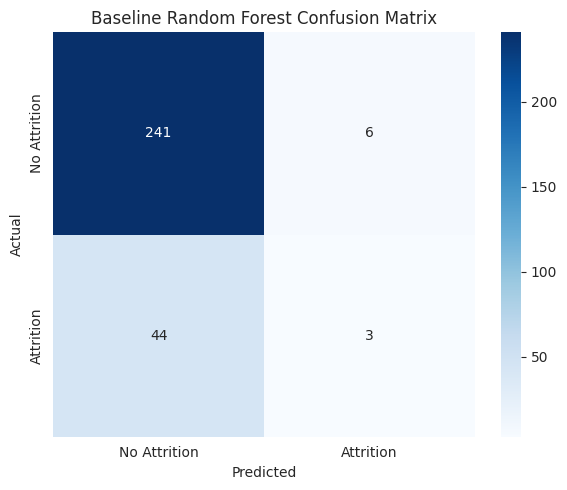

In [41]:
cm_baseline = confusion_matrix(y_test, y_pred_baseline)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_baseline,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Baseline Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

## Improved Hyperparameter Tuning

GridSearchCV is used together with Stratified K-Fold cross-validation.  
Since the dataset is imbalanced, **F1-score** is used as the tuning metric instead of accuracy.

In [42]:
# =========================
# 16. IMPROVED HYPERPARAMETER TUNING
# =========================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 15],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
    "class_weight": [None, "balanced", "balanced_subsample"]
}

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=skf,
    scoring="f1",
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print("\nBest Parameters:", grid_search.best_params_)
print(f"Best Cross-Validation F1 Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 486 candidates, totalling 2430 fits

Best Parameters: {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Best Cross-Validation F1 Score: 0.4147


## Optimized Random Forest Model

The best estimator identified through GridSearchCV is used as the optimized final model and evaluated on the test set.

In [43]:
# =========================
# 17. OPTIMIZED RANDOM FOREST MODEL
# =========================
rf_best = grid_search.best_estimator_

y_pred = rf_best.predict(X_test_scaled)
y_prob = rf_best.predict_proba(X_test_scaled)[:, 1]

acc = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
auc = roc_auc_score(y_test, y_prob)

print("Optimized Random Forest Results")
print("=" * 40)
print(f"Accuracy  : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print(f"ROC-AUC   : {auc:.4f}")

Optimized Random Forest Results
Accuracy  : 0.8265 (82.65%)
Precision : 0.4286
Recall    : 0.2553
F1-Score  : 0.3200
ROC-AUC   : 0.7625


In [44]:
print("Classification Report (Optimized):\n")
print(classification_report(
    y_test,
    y_pred,
    target_names=["No Attrition", "Attrition"],
    zero_division=0
))

Classification Report (Optimized):

              precision    recall  f1-score   support

No Attrition       0.87      0.94      0.90       247
   Attrition       0.43      0.26      0.32        47

    accuracy                           0.83       294
   macro avg       0.65      0.60      0.61       294
weighted avg       0.80      0.83      0.81       294



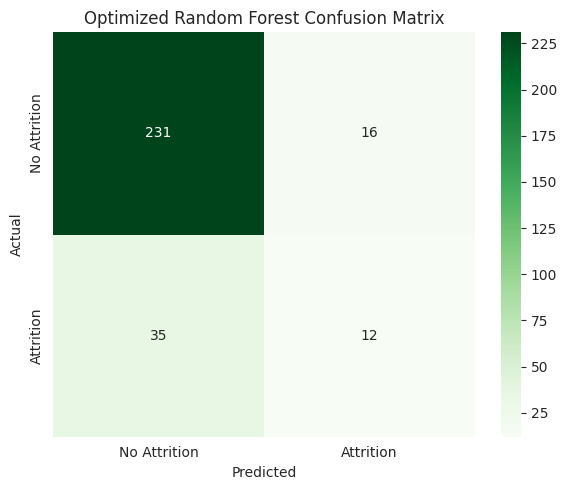

In [45]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Optimized Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

In [46]:
plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["No Attrition", "Attrition"],
    yticklabels=["No Attrition", "Attrition"]
)
plt.title("Optimized Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.savefig(f"{project_folder}/optimized_confusion_matrix.png")
plt.close()

## Threshold Tuning

Threshold tuning is applied to improve the detection of attrition cases by adjusting the probability cutoff used for classification.

In [47]:
# =========================
# 18. THRESHOLD TUNING
# =========================
threshold = 0.40
y_pred_thresh = (y_prob >= threshold).astype(int)

acc_thresh = accuracy_score(y_test, y_pred_thresh)
precision_thresh = precision_score(y_test, y_pred_thresh, zero_division=0)
recall_thresh = recall_score(y_test, y_pred_thresh, zero_division=0)
f1_thresh = f1_score(y_test, y_pred_thresh, zero_division=0)

print(f"Threshold Tuned Results (Threshold = {threshold})")
print("=" * 45)
print(f"Accuracy  : {acc_thresh:.4f} ({acc_thresh*100:.2f}%)")
print(f"Precision : {precision_thresh:.4f}")
print(f"Recall    : {recall_thresh:.4f}")
print(f"F1-Score  : {f1_thresh:.4f}")

Threshold Tuned Results (Threshold = 0.4)
Accuracy  : 0.8299 (82.99%)
Precision : 0.4667
Recall    : 0.4468
F1-Score  : 0.4565


## ROC Curve

The ROC curve evaluates the classifier’s ability to distinguish between the two classes across different thresholds.

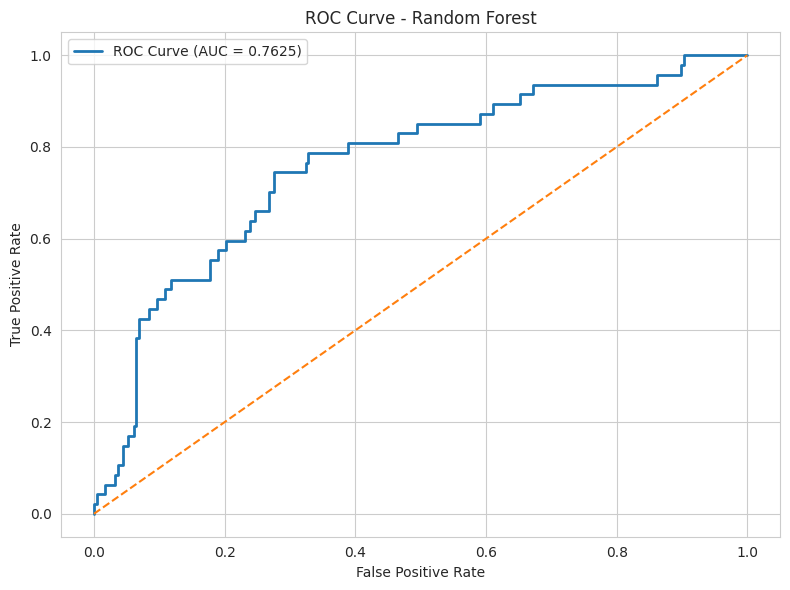

In [48]:
# =========================
# 19. ROC CURVE
# =========================
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.show()

In [49]:
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, lw=2, label=f"ROC Curve (AUC = {auc:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()
plt.tight_layout()
plt.savefig(f"{project_folder}/roc_curve_random_forest.png")
plt.close()

## Cross-Validation

10-fold cross-validation is applied to assess the robustness and stability of the optimized model.

In [50]:
# =========================
# 20. 10-FOLD CROSS-VALIDATION
# =========================
cv_scores = cross_val_score(rf_best, X, y, cv=10, scoring="accuracy")

print("10-Fold Cross-Validation Scores:")
for i, score in enumerate(cv_scores, 1):
    print(f"Fold {i:2d}: {score:.4f}")

print(f"\nMean Accuracy : {cv_scores.mean():.4f}")
print(f"Std Deviation : {cv_scores.std():.4f}")

10-Fold Cross-Validation Scores:
Fold  1: 0.8299
Fold  2: 0.8571
Fold  3: 0.8571
Fold  4: 0.8639
Fold  5: 0.8503
Fold  6: 0.8435
Fold  7: 0.8367
Fold  8: 0.8435
Fold  9: 0.8776
Fold 10: 0.8776

Mean Accuracy : 0.8537
Std Deviation : 0.0153


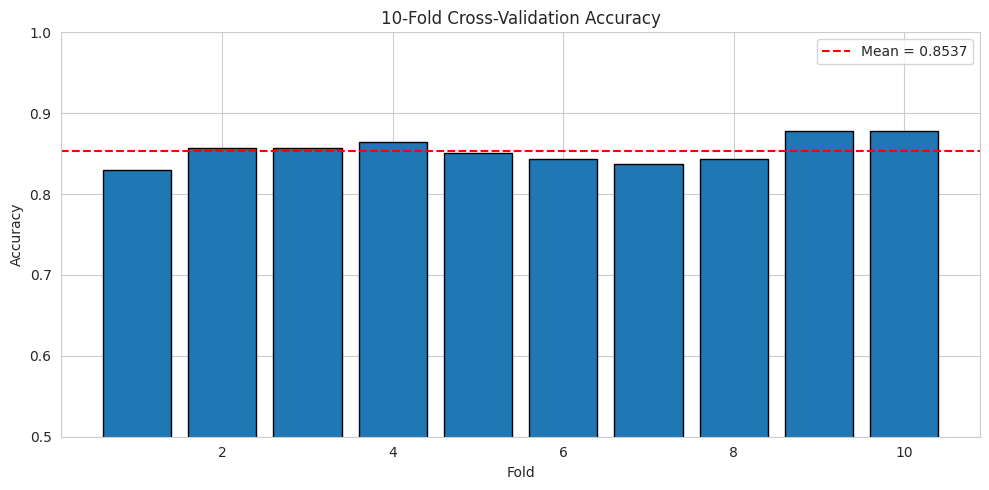

In [51]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores, edgecolor="black")
plt.axhline(cv_scores.mean(), color="red", linestyle="--", label=f"Mean = {cv_scores.mean():.4f}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("10-Fold Cross-Validation Accuracy")
plt.ylim([0.5, 1.0])
plt.legend()
plt.tight_layout()
plt.show()

In [52]:
plt.figure(figsize=(10, 5))
plt.bar(range(1, 11), cv_scores, edgecolor="black")
plt.axhline(cv_scores.mean(), color="red", linestyle="--", label=f"Mean = {cv_scores.mean():.4f}")
plt.xlabel("Fold")
plt.ylabel("Accuracy")
plt.title("10-Fold Cross-Validation Accuracy")
plt.ylim([0.5, 1.0])
plt.legend()
plt.tight_layout()
plt.savefig(f"{project_folder}/cross_validation_scores.png")
plt.close()

## Feature Importance

Feature importance scores are extracted from the Random Forest model to identify the most influential features affecting employee attrition.

In [53]:
# =========================
# 21. FEATURE IMPORTANCE
# =========================
feature_imp = pd.Series(
    rf_best.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print("Top 15 Important Features:")
print(feature_imp.head(15))

Top 15 Important Features:
IncomeToDistanceRatio        0.048483
Age                          0.048373
MonthlyIncome                0.047996
Log_MonthlyIncome            0.044543
OverTime                     0.043762
Log_IncomeToDistanceRatio    0.041815
TotalWorkingYears            0.039546
Log_TotalWorkingYears        0.035899
YearsWithManagerRatio        0.034762
DailyRate                    0.034438
TotalSatisfaction            0.032884
MonthlyRate                  0.032752
YearsAtCompany               0.030992
StockOptionLevel             0.030936
IncomePerYearAtCompany       0.028658
dtype: float64


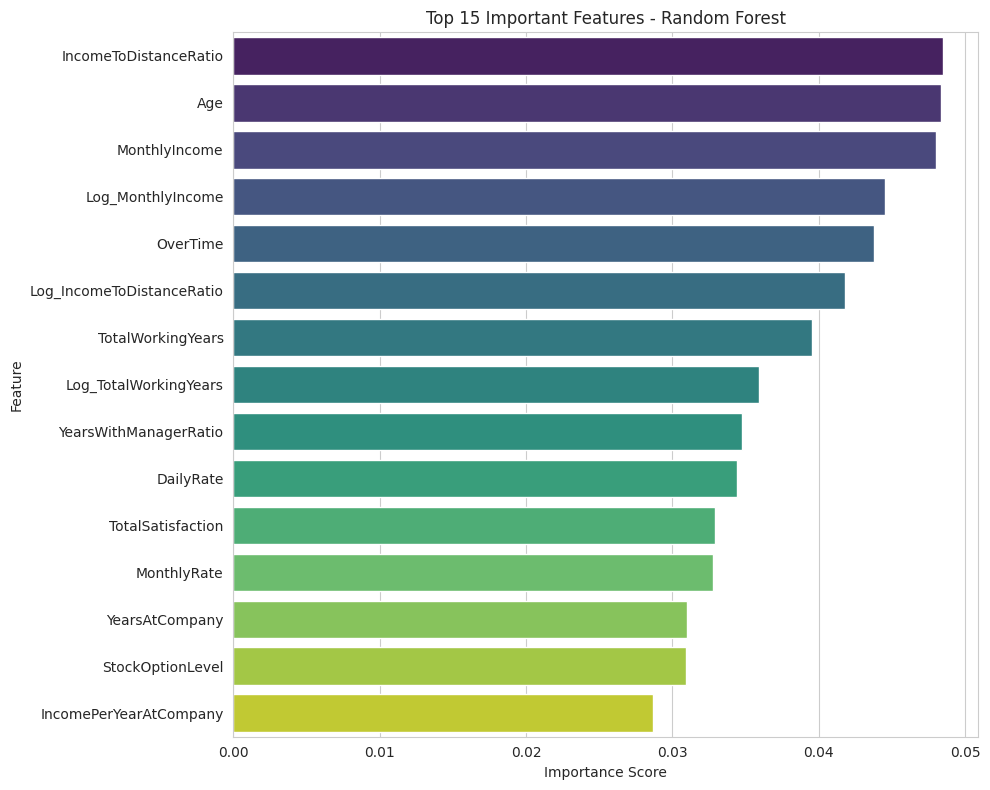

In [54]:
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_imp.values[:15], y=feature_imp.index[:15], palette="viridis")
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

In [55]:
plt.figure(figsize=(10, 8))
sns.barplot(x=feature_imp.values[:15], y=feature_imp.index[:15], palette="viridis")
plt.title("Top 15 Important Features - Random Forest")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig(f"{project_folder}/feature_importance_random_forest.png")
plt.close()

In [56]:
feature_imp.to_csv(f"{project_folder}/feature_importance.csv")
print("Feature importance values saved.")

Feature importance values saved.


## Prediction Output

The model predictions on the test set are stored in a CSV file for further analysis and record keeping.

In [57]:
# =========================
# 22. PREDICTION OUTPUT TABLE (FINAL MODEL)
# =========================
pred_df = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Optimized": y_pred,
    "Predicted_Final": y_pred_thresh,
    "Predicted_Probability": y_prob
})

pred_df["Actual_Label"] = pred_df["Actual"].map({1: "Yes", 0: "No"})
pred_df["Predicted_Optimized_Label"] = pred_df["Predicted_Optimized"].map({1: "Yes", 0: "No"})
pred_df["Predicted_Final_Label"] = pred_df["Predicted_Final"].map({1: "Yes", 0: "No"})

print("Sample predictions from final threshold-tuned model:")
pred_df[[
    "Actual_Label",
    "Predicted_Optimized_Label",
    "Predicted_Final_Label",
    "Predicted_Probability"
]].head(10)

Sample predictions from final threshold-tuned model:


,Actual_Label,Predicted_Optimized_Label,Predicted_Final_Label,Predicted_Probability
0,No,Yes,Yes,0.729668
1,No,No,No,0.152752
2,No,No,No,0.132275
3,No,No,No,0.086312
4,Yes,No,Yes,0.444988
5,No,No,No,0.296322
6,No,No,No,0.097921
7,No,No,No,0.097980
8,No,No,No,0.078290
9,No,Yes,Yes,0.754461


In [58]:
pred_df.to_csv(f"{project_folder}/attrition_predictions.csv", index=False)
print("Prediction file saved to Google Drive.")

Prediction file saved to Google Drive.


## Baseline vs Optimized Model Comparison

The baseline and optimized Random Forest models are compared to observe the effect of tuning.

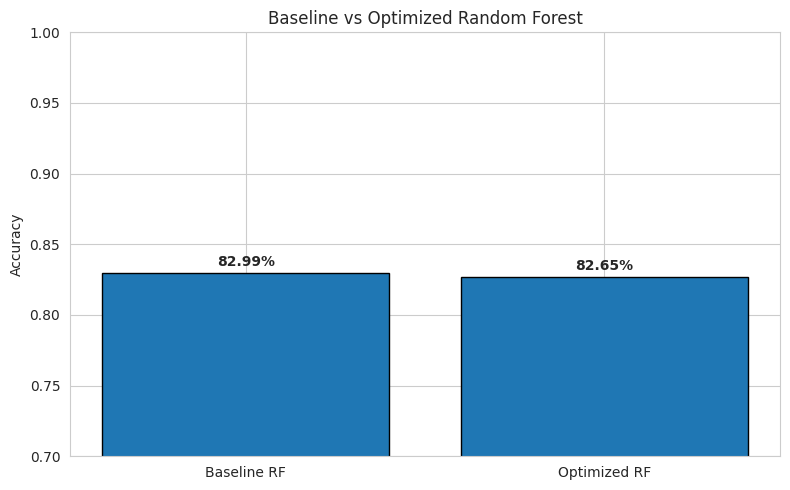

Improvement: -0.34 percentage points


In [59]:
# =========================
# 23. BASELINE VS OPTIMIZED COMPARISON
# =========================
models = ["Baseline RF", "Optimized RF"]
accs = [baseline_acc, acc]

plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, edgecolor="black")

for bar, a in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        a + 0.005,
        f"{a*100:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim([0.7, 1.0])
plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Random Forest")
plt.tight_layout()
plt.show()

print(f"Improvement: {(acc - baseline_acc)*100:.2f} percentage points")

In [60]:
plt.figure(figsize=(8, 5))
bars = plt.bar(models, accs, edgecolor="black")

for bar, a in zip(bars, accs):
    plt.text(
        bar.get_x() + bar.get_width()/2,
        a + 0.005,
        f"{a*100:.2f}%",
        ha="center",
        fontweight="bold"
    )

plt.ylim([0.7, 1.0])
plt.ylabel("Accuracy")
plt.title("Baseline vs Optimized Random Forest")
plt.tight_layout()
plt.savefig(f"{project_folder}/baseline_vs_optimized_accuracy.png")
plt.close()

## Save Model and Scaler

The trained model and scaler are saved so that the experiment can be reproduced later without retraining.

In [61]:
# =========================
# 24. SAVE MODEL AND SCALER
# =========================
joblib.dump(rf_best, f"{project_folder}/random_forest_model.pkl")
joblib.dump(scaler, f"{project_folder}/scaler.pkl")

print("Model and scaler saved to Google Drive.")

Model and scaler saved to Google Drive.


## Final Results Summary

A final summary table is generated to store the model’s performance metrics.

In [62]:
summary_data = {
    "Model Version": [
        "Baseline Random Forest",
        "Optimized Random Forest",
        "Final Threshold-Tuned Random Forest"
    ],
    "Threshold": [
        "0.50 (default)",
        "0.50 (default)",
        f"{threshold:.2f}"
    ],
    "Accuracy": [
        baseline_acc,
        acc,
        acc_thresh
    ],
    "Precision": [
        baseline_precision,
        precision,
        precision_thresh
    ],
    "Recall": [
        baseline_recall,
        recall,
        recall_thresh
    ],
    "F1-Score": [
        baseline_f1,
        f1,
        f1_thresh
    ]
}

summary_df = pd.DataFrame(summary_data)
summary_df.to_csv(f"{project_folder}/final_results_summary.csv", index=False)

print("Final results summary saved.")
summary_df

Final results summary saved.


,Model Version,Threshold,Accuracy,Precision,Recall,F1-Score
0,Baseline Random Forest,0.50 (default),0.829932,0.333333,0.063830,0.107143
1,Optimized Random Forest,0.50 (default),0.826531,0.428571,0.255319,0.320000
2,Final Threshold-Tuned Random Forest,0.40,0.829932,0.466667,0.446809,0.456522


## Results Interpretation

Three versions of the Random Forest model were evaluated:

- **Baseline model**: initial model using default settings
- **Optimized model**: tuned using GridSearchCV with F1-score
- **Final threshold-tuned model**: optimized model with adjusted classification threshold

Since the dataset is imbalanced, the final threshold-tuned model is selected as the best version because it provides the strongest balance between precision, recall, and F1-score.

In [63]:
# =========================
# 25. FINAL RESULTS SUMMARY
# =========================
print("═" * 70)
print("                  FINAL RESULTS SUMMARY")
print("═" * 70)
print("Dataset            : IBM HR Analytics Attrition Dataset")
print("Algorithm          : Random Forest Classifier")
print(f"Training Samples   : {X_train.shape[0]}")
print(f"Testing Samples    : {X_test.shape[0]}")
print(f"Features Used      : {X.shape[1]}")
print(f"Best Parameters    : {grid_search.best_params_}")
print(f"Threshold Used     : {threshold:.2f}")
print("─" * 70)

print("Baseline Random Forest")
print(f"Accuracy           : {baseline_acc*100:.2f}%")
print(f"Precision          : {baseline_precision:.4f}")
print(f"Recall             : {baseline_recall:.4f}")
print(f"F1-Score           : {baseline_f1:.4f}")
print(f"ROC-AUC            : {baseline_auc:.4f}")
print("─" * 70)

print("Optimized Random Forest")
print(f"Accuracy           : {acc*100:.2f}%")
print(f"Precision          : {precision:.4f}")
print(f"Recall             : {recall:.4f}")
print(f"F1-Score           : {f1:.4f}")
print(f"ROC-AUC            : {auc:.4f}")
print("─" * 70)

print("Final Threshold-Tuned Random Forest")
print(f"Accuracy           : {acc_thresh*100:.2f}%")
print(f"Precision          : {precision_thresh:.4f}")
print(f"Recall             : {recall_thresh:.4f}")
print(f"F1-Score           : {f1_thresh:.4f}")
print(f"ROC-AUC            : {auc:.4f}")
print("─" * 70)

print(f"CV Mean Accuracy   : {cv_scores.mean()*100:.2f}% ± {cv_scores.std()*100:.2f}%")
print("═" * 70)
print("All outputs saved to:", project_folder)

══════════════════════════════════════════════════════════════════════
                  FINAL RESULTS SUMMARY
══════════════════════════════════════════════════════════════════════
Dataset            : IBM HR Analytics Attrition Dataset
Algorithm          : Random Forest Classifier
Training Samples   : 1176
Testing Samples    : 294
Features Used      : 41
Best Parameters    : {'class_weight': 'balanced_subsample', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 4, 'min_samples_split': 2, 'n_estimators': 100}
Threshold Used     : 0.40
──────────────────────────────────────────────────────────────────────
Baseline Random Forest
Accuracy           : 82.99%
Precision          : 0.3333
Recall             : 0.0638
F1-Score           : 0.1071
ROC-AUC            : 0.7778
──────────────────────────────────────────────────────────────────────
Optimized Random Forest
Accuracy           : 82.65%
Precision          : 0.4286
Recall             : 0.2553
F1-Score           : 0.3200
ROC-A